<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Metodo_de_Uniformizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;">**MÉTODO DE UNIFORMIZACIÓN**</span>

<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span> Implementar y comparar dos métodos numéricos para el cálculo de la matriz de
probabilidades de transición P(t) en cadenas de Markov en tiempo continuo,
aplicando el **método de uniformización** (o randomización) a una matriz de
tasas R dada.

Dado ${X(t), t\geq0}$ queremos calcular la pmf de $X(t)$.
Supongamos conocida $X(0)$. Queremos:
* $$P(X(t)=j)=\sum_{i=1}^{n} P(X(t)= j  \lvert  X(0)=i)P(x(0))= i,     1 \leq j \leq N $$

Entonces, necesitamos calcular $$ P(X(t)= j  \lvert  X(0)=i)=p_{ij}(t)$$
* $P(t)=\[p_{ij}(t)]\$


y recordar que $R=\[r_{ij}]\$

Sea $r \geq max \{r_i\},  1 \leq j \leq N$



Definimos $ \hat{P}=  [ \hat{p}_{ij}]\ $ así:



<span style="color:orange;">**Teorema:** La matriz de probabilidades de transición</span>
$ P(t)= [p_{ij}(t)]\ $ esta dada por:
$$ P(t)= \sum_{k=1}^{∞} e ^{-rt} \frac{(rt)^k}{k!}  \hat{P}^k$$

Este **Teorema** nos permite aproximar $P(t)$ usando $M$ términos de la serie. ¿Cómo elegir $M$?
$$ M\approx max \{ rt+5* \sqrt{rt}, 20 \} $$

****

<span style="color:magenta;">**Ejercicio 3 para programar :**</span>

Sea la matriz
$$
R=
\begin{bmatrix}
0 & 2 & 3 & 0 \\
4 & 0 & 2 & 0 \\
0 & 2 & 0 & 2 \\
1 & 0 & 3 & 0
\end{bmatrix}
$$

1.   Escribir $P(t)$ usando el teorema anterior
2.   Calcular $P(0.5), P(1)$ y $P(5)$
3.   Verificar que $P(1)=P(0.5)P(0.5)$ según las ecuaciones de **Chapman-Kolmogorov**





In [ ]:
#Importamos la librerias necesarias
import sympy as sp
from sympy import Matrix, symbols, exp, factorial, sqrt, eye, zeros

In [ ]:
# Definimos la matriz de R
R=sp.Matrix([[0, 2,3,0], [4,0,2,0] , [0,2,0,2] , [1,0,3,0]])
R

Matrix([
[0, 2, 3, 0],
[4, 0, 2, 0],
[0, 2, 0, 2],
[1, 0, 3, 0]])


Escribimos $P(t)$ usando el teorema anterior.

Donde en este caso el $r \geq max \{r_i\},  1 \leq j \leq N$
es $r=6$

In [ ]:
r_i = [sum(row) for row in R.tolist()] #sumamos fila a fila para obtener r max
r = max(r_i)
print(f"Sumas Individuales (r_i): {r_i}")
print(f"Maxima valor de la suma (r): {r}")

Sumas Individuales (r_i): [5, 6, 4, 4]
Maxima valor de la suma (r): 6


Aplicamos el **Teorema** para convervir a R en una matriz estocástica

In [ ]:
n_estados = R.shape[0]
I = sp.eye(n_estados)  # Matriz identidad del tamaño del número de estados

P_hat = sp.zeros(n_estados, n_estados)
for i in range(n_estados):
    for j in range(n_estados):
        if i == j:
            # Calcula la probabilidad de permanecer en el mismo estado
            P_hat[i, j] = 1 - r_i[i] / r
        else:
            # Calcula la probabilidad de transición entre estados distintos
            P_hat[i, j] = R[i, j] / r

print("Matriz estocástica P_hat:")
display(P_hat)

Matriz estocástica P_hat:


Matrix([
[1/6, 1/3, 1/2,   0],
[2/3,   0, 1/3,   0],
[  0, 1/3, 1/3, 1/3],
[1/6,   0, 1/2, 1/3]])

Verificamos que la matriz $P^̂$ sea estocastica es decir sus renglones sumen 1


In [ ]:
print("Verificación: cada fila debe sumar 1")
for i in range(n_estados):
    suma_fila = sum(P_hat[i, j] for j in range(n_estados))
    print(f"Fila {i}: suma = {sp.simplify(suma_fila)}")
print("\n")

Verificación: cada fila debe sumar 1
Fila 0: suma = 1
Fila 1: suma = 1
Fila 2: suma = 1
Fila 3: suma = 1




Creamos una Función para calcular $P(t)$ usando el método de uniformización para un tiempo dado:

    """
    Parámetros:
    -----------
    t_valor : Tiempo en el que se evalúa la matriz de transición
    R_matrix : Matriz de tasas
    
    Retorna:
    --------
    sympy Matrix
        Matriz P(t) de probabilidades de transición
    """
    
Para calcular $P(0.5), P(1)$ y $P(5)$

In [ ]:
def calcular_P_t(t_valor, R_matrix):
    # --- 1. Recalculamos r y P̂ (para independencia de la función) ---
    r_i_local = [sum(row) for row in R_matrix.tolist()]
    r_local = max(r_i_local)
    n_estados_local = R_matrix.shape[0]

    # Construimos P̂ local
    P_hat_local = sp.zeros(n_estados_local, n_estados_local)
    for i in range(n_estados_local):
        for j in range(n_estados_local):
            if i == j:
                P_hat_local[i, j] = 1 - r_i_local[i] / r_local
            else:
                P_hat_local[i, j] = R_matrix[i, j] / r_local

    # --- 2. Determinamos el número de términos M para la serie ---
    # Fórmula: M ≈ max(rt + 5√(rt), 20)
    # Esto garantiza que el error de truncamiento sea despreciable
    rt = r_local * t_valor
    M = int(max(rt + 5 * sp.sqrt(rt), 20))

    print(f"Para t = {t_valor}:")
    print(f"  rt = {float(rt):.2f}")
    print(f"  M = {M} términos")

    # --- 3. Calculamos la serie truncada ---
    # P(t) = Σ_{k=0}^{M} e^{-rt} (rt)^k/k! · P̂^k
    P_t = sp.zeros(n_estados_local, n_estados_local)  # Inicializar P(t)
    potencia_P_hat = sp.eye(n_estados_local)          # P̂^0 = I

    # Sumam os los términos desde k=0 hasta M
    for k in range(M + 1):  # Incluir k = M
        # Calcular coeficiente de Poisson: e^{-rt} * (rt)^k / k!
        coeficiente = sp.exp(-rt) * (rt**k / sp.factorial(k))

        # Añadir término: coeficiente * P̂^k
        P_t += coeficiente * potencia_P_hat

        # Preparar P̂^(k+1) para la siguiente iteración
        potencia_P_hat = potencia_P_hat * P_hat_local

    return P_t


In [ ]:
# Calculamos P(t) para los tiempos solicitados: t = 0.5, 1, 5
print("CÁLCULO DE P(t) PARA DIFERENTES TIEMPOS")

t_vals = [0.5, 1, 5]
resultados = {}

for t in t_vals:
    P_t = calcular_P_t(t, R)
    resultados[t] = P_t

    print(f"\nP({t}) =")
    P_t_numerica = sp.N(P_t, 12)  # 12 decimales
    display(P_t_numerica)


CÁLCULO DE P(t) PARA DIFERENTES TIEMPOS
Para t = 0.5:
  rt = 3.00
  M = 20 términos

P(0.5) =


Matrix([
[0.250608679645, 0.216964598159, 0.386656935582, 0.145769786602],
[0.253134844845, 0.238360983781, 0.374409239718, 0.134094931645],
[0.169119496516, 0.193614888245, 0.420301017069, 0.216964598159],
[0.158017482467, 0.157444641559, 0.398331790539, 0.286206085423]])

Para t = 1:
  rt = 6.00
  M = 20 términos

P(1) =


Matrix([
[0.206151120157, 0.203902026694, 0.398709595696, 0.191235802346],
[ 0.20828421449, 0.205340699017, 0.397899174557, 0.188474456828],
[ 0.19675849338, 0.198379335659,  0.40095868916, 0.203902026694],
[0.192046223485, 0.193997147863, 0.401470941214, 0.212484232331]])

Para t = 5:
  rt = 30.00
  M = 57 términos

P(5) =


Matrix([
[0.199999251328, 0.199999250687, 0.399998498066, 0.199999246177],
[0.199999252039, 0.199999251178, 0.399998497916, 0.199999245124],
[0.199999248282, 0.199999248581, 0.399998498707, 0.199999250687],
[0.199999246326, 0.199999247229, 0.399998499119, 0.199999253583]])

Procedemos que los renglones para cada tiempo sus probabilidades sumen uno para verificar que estamos bien.

In [ ]:
# Verificar que cada fila suma 1 (propiedad de matriz estocástica)
print("Verificamos (sumas de filas deben ser 1):")
for i in range(n_estados):
    suma_fila = sum(P_t[i, j] for j in range(n_estados))
    print(f"  Fila {i}: {sp.simplify(suma_fila)} = {float(sp.N(suma_fila, 6))}")

Verificamos (sumas de filas deben ser 1):
  Fila 0: 5165385233600559257803742011942922257289841715102789*exp(-30)/483359089454045704296419725086376161169 = 0.9999961853027344
  Fila 1: 5165385233600559257803742011942922257289841715102789*exp(-30)/483359089454045704296419725086376161169 = 0.9999961853027344
  Fila 2: 5165385233600559257803742011942922257289841715102789*exp(-30)/483359089454045704296419725086376161169 = 0.9999961853027344
  Fila 3: 5165385233600559257803742011942922257289841715102789*exp(-30)/483359089454045704296419725086376161169 = 0.9999961853027344


Como podemos observar las sumas son aproximadas a $1$ debido a los decimales que estamos utilizando pero se comprueba que si lo suman

### Verificamos si se cumple las Ecuaciones de Chapman-Kolmogorov

Verificamos numéricamente la propiedad de **semigrupo** de una cadena de Markov en tiempo continuo (CMTC):

$$
P(t+s)=P(t),P(s)
$$

En este caso comprobamos

$$
P(1)=P(0.5),P(0.5)
$$


In [ ]:
# Chapman-Kolmogorov: P(t1 + t2) = P(t1) · P(t2)
# En particular: P(1) = P(0.5) · P(0.5)
print("VERIFICACIÓN DE LAS ECUACIONES DE CHAPMAN-KOLMOGOROV")
print("Teorema: P(t1 + t2) = P(t1) · P(t2)")
print("Verificando que P(1) = P(0.5) · P(0.5)\n")

# Obtener las matrices
P_05 = resultados[0.5]
P_1 = resultados[1]

# Calcular P(0.5) · P(0.5)
P_05_por_P_05 = P_05 * P_05

print("P(0.5) · P(0.5) =")
display(sp.N(P_05_por_P_05, 6))

print("\nP(1) =")
display(sp.N(P_1, 6))

VERIFICACIÓN DE LAS ECUACIONES DE CHAPMAN-KOLMOGOROV
Teorema: P(t1 + t2) = P(t1) · P(t2)
Verificando que P(1) = P(0.5) · P(0.5)

P(0.5) · P(0.5) =


Matrix([
[0.206151, 0.203902,  0.39871, 0.191236],
[0.208284, 0.205341,   0.3979, 0.188475],
[0.196759,  0.19838, 0.400959, 0.203902],
[0.192047, 0.193997, 0.401471, 0.212485]])


P(1) =


Matrix([
[0.206151, 0.203902,  0.39871, 0.191236],
[0.208284, 0.205341, 0.397899, 0.188474],
[0.196759, 0.198379, 0.400959, 0.203902],
[0.192046, 0.193997, 0.401471, 0.212484]])

Calculamos el error para ver que tan lejano o cerca estamos del resultado exacto

In [ ]:
# Calcular la diferencia (error)
diferencia = P_1 - P_05_por_P_05
error_maximo = max(abs(sp.N(diferencia[i, j], 10))
                   for i in range(n_estados)
                   for j in range(n_estados))

print(f"\nDiferencia P(1) - [P(0.5)·P(0.5)]:")
display(sp.N(diferencia, 6))


Diferencia P(1) - [P(0.5)·P(0.5)]:


Matrix([
[-2.91017e-7, -2.91017e-7, -5.82033e-7, -2.91017e-7],
[-2.91017e-7, -2.91017e-7, -5.82033e-7, -2.91017e-7],
[-2.91017e-7, -2.91017e-7, -5.82033e-7, -2.91017e-7],
[-2.91017e-7, -2.91017e-7, -5.82033e-7, -2.91017e-7]])

In [ ]:
print(f"\nError máximo absoluto: {error_maximo:.2e}")
# Verificar si cumple Chapman-Kolmogorov dentro de la precisión numérica
if error_maximo < 1e-6:
    print("\n VERIFICADO: Se cumple Chapman-Kolmogorov con alta precisión")
elif error_maximo < 1e-5:
    print("\n CUMPLE APROXIMADAMENTE: Error pequeño, dentro de lo esperado")
else:
    print("\n NO SE CUMPLE: Error significativo, aumentar M para mejorar")


Error máximo absoluto: 5.82e-7

 VERIFICADO: Se cumple Chapman-Kolmogorov con alta precisión


 La diferencia entre ambas matrices fue prácticamente nula , lo cual confirma la consistencia del cálculo de las probabilidades de transición y la validez de la propiedad semigrupo $P(t+s)=P(t)P(s)$.


### <span style="color:orange;"> **Teorema 4 (Cotas de error para $P(t)$)**</span>

Para un $t \geq 0$ fijo, sea

$$
P^{M}(t)=\left[p_{ij}^{M}(t)\right]
=
\sum_{k=0}^{M}
e^{-rt}\frac{(rt)^k}{k!}\,\hat{P}^{\,k}
$$

 <span style="color:magenta;">**Ejercicio para programar** Este teorema se puede usar así:</span>

   Suponga que se desea calcular $P(t)$ con una tolerancia $\varepsilon$.
   
   Elija $M$ tal que

$$
\sum_{k=M+1}^{\infty}
e^{-rt}\frac{(rt)^k}{k!}
\leq \varepsilon.
$$



Y se puede implementar de acuerdo al siguiente **algoritmo de uniformización para $P(t)$**:

1. Dados $R,t,0<\varepsilon<1$.

2. Calcular $r$ usando la igualdad en la definición.

3. Calcular $\hat{P}$.

4. Inicializar

$$
A=\hat{P},
\qquad
B=e^{-rt}I,
\qquad
c=e^{-rt},
\qquad
\text{sum}=c,
\qquad
k=1.
$$

5. Mientras $\text{sum}<1-\varepsilon$ hacer:

$$
c=c\,\frac{rt}{k}
$$

$$
B=B+cA
$$

$$
A=A\hat{P}
$$

$$
\text{sum}=\text{sum}+c
$$

$$
k=k+1
$$

6. $B$ está a $\varepsilon$ de $P(t)$.

In [ ]:
#Importamos algunas librerias necesarias
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt

Usando la matriz
$$
R=
\begin{bmatrix}
0 & 2 & 3 & 0 \\
4 & 0 & 2 & 0 \\
0 & 2 & 0 & 2 \\
1 & 0 & 3 & 0
\end{bmatrix}
$$

Creamos una Función para calcular parámetros de uniformización igual a la que se uso anteriormente en el ejercicio:


In [ ]:
def calcular_parametros_uniformizacion(R):
    n = R.shape[0]

    # Calcular tasas de salida por estado (suma de cada fila)
    tasas_salida = np.sum(R, axis=1)
    r = np.max(tasas_salida)

    # Construir P̂ = I + (1/r) R
    I = np.eye(n)
    P_hat = I + (1/r) * R

    return r, P_hat

Implementamos el algoritmo de uniformización con tolerancia $ε$ la función contendra lo siguiente:

    """
    Calculamos P(t) usando el método de uniformización con control de error.
    
    Implementamos el algoritmo descrito en el Teorema 4:
    - Calcula la serie de Poisson hasta que la suma acumulada alcanza 1-ε
    - Garantiza un error menor o igual a ε
    
    Parámetros:
    -----------
    R :
        Matriz de tasas (generador infinitesimal)
    t :
        Tiempo en el que evaluar P(t)
    epsilon :
        Tolerancia para el error de truncamiento (0 < ε < 1)
    Retorna:
    --------
    B :
        Aproximación a P(t) con error ≤ ε
    M : int
        Número de términos utilizados (M = k-1)
    error_real :
        Cota superior real del error (cola de Poisson)
    """

In [ ]:
def uniformizacion_con_tolerancia(R, t, epsilon=1e-6, verbose=True):
    if isinstance(R, sp.Matrix):
        R_np = np.array(R.tolist(), dtype=float)
    else:
        R_np = R

    # --- Paso 1: Calcular parámetros r y P̂ ---
    r, P_hat = calcular_parametros_uniformizacion(R_np) # Pass numpy array
    n = R_np.shape[0] # Use R_np.shape[0]
    rt = r * t
    # --- Paso 2: Inicializar variables según algoritmo ---
    A = P_hat.copy()                    # A = P̂
    B = np.exp(-rt) * np.eye(n)         # B = e^{-rt} · I
    c = np.exp(-rt)                     # c = e^{-rt}
    suma = c                            # suma = c (término k=0)
    k = 1                               # k = 1 (próximo término)

    # --- Paso 3: Bucle hasta que suma alcance 1-ε ---
    while suma < 1 - epsilon:
        # Actualizar coeficiente de Poisson: c = c * (rt / k)
        c = c * (rt / k)

        # Actualizar B: B = B + c * A
        B = B + c * A

        # Actualizar A: A = A @ P_hat (siguiente potencia)
        A = A @ P_hat

        # Actualizar suma acumulada
        suma = suma + c
        k = k + 1

    # Número de términos utilizados (M = k-1 porque k se incrementa al final)
    M = k - 1

    # --- Paso 4: Calcular error real (cola de Poisson) ---
    # El error está acotado por la probabilidad de que Poisson(rt) > M
    error_real = 1 - poisson.cdf(M, rt)

    if verbose:
        print(f"\n--- Resultados ---")
        print(f"Número de términos utilizados: M = {M}")
        print(f"Suma acumulada final: {suma:.10f}")
        print(f"Error real acotado (cola de Poisson): {error_real:.2e}")
        print(f"Error real ≤ ε? {error_real <= epsilon} (ε={epsilon})")
        print()

    return B, M, error_real

 verificamos Chapman-Kolmogorov

In [ ]:
def verificar_chapman_kolmogorov(P_t1, P_t2, P_t1_mas_t2, tolerancia=1e-6):
  # Calcular producto P(t1) · P(t2)
    producto = P_t1 @ P_t2

    # Calcular diferencia
    diferencia = P_t1_mas_t2 - producto
    error_max = np.max(np.abs(diferencia))

    cumple = error_max <= tolerancia

    return cumple, error_max

Aplicar el algoritmo para diferentes tiempos los decritos anteriormente en el **ejercicio 3**.


In [ ]:
# Tiempos a evaluar (según el ejercicio)
tiempos = [0.5, 1.0, 5.0]
epsilon = 1e-8  # Tolerancia muy pequeña para alta precisión
# Almacenamos los  resultados
resultados = {}

for t in tiempos:
    P_t, M, error = uniformizacion_con_tolerancia(R, t, epsilon, verbose=True)
    resultados[t] = P_t

    print(f"P({t}) ≈")
    print(np.round(P_t, 8))
    print("\n" + "-" * 70 + "\n")


--- Resultados ---
Número de términos utilizados: M = 17
Suma acumulada final: 0.9999999964
Error real acotado (cola de Poisson): 3.57e-09
Error real ≤ ε? True (ε=1e-08)

P(0.5) ≈
[[3.18530345 2.93252787 3.93926236 1.34334037]
 [3.71344597 3.77765681 4.38288244 1.39495982]
 [1.88218664 2.23127267 3.56174078 1.6962017 ]
 [1.59720021 1.6662706  3.21597273 2.16678096]]

----------------------------------------------------------------------


--- Resultados ---
Número de términos utilizados: M = 24
Suma acumulada final: 0.9999999941
Error real acotado (cola de Poisson): 5.89e-09
Error real ≤ ε? True (ε=1e-08)

P(1.0) ≈
[[30.59253455 31.4434785  43.74647738 17.96011924]
 [36.32998257 37.26009775 51.27625055 20.71245928]
 [23.69135603 24.71927612 35.33080576 15.35601207]
 [20.78657571 21.76206404 32.01407772 14.61834647]]

----------------------------------------------------------------------


--- Resultados ---
Número de términos utilizados: M = 65
Suma acumulada final: 0.9999999905
Error

<span style="color:magenta;">**Ejercicio**</span>

Repita el **ejercicio 3** aplicando este algoritmo con una tolerancia $ε = 0.00001$ (indique el valor correspondiente de M en cada caso). Compare los resultados.

In [ ]:
print("ANÁLISIS DE CONVERGENCIA vs TOLERANCIA ε")
print("=" * 70)
print("Estudio de cómo varía M (número de términos) con la tolerancia ε")
print()

tiempos_a_probar = [0.5, 1.0, 5.0]
tolerancias = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10] # 1e-4, es la que se nos pide en el ejercicio

for t_val in tiempos_a_probar:
    print(f"Resultados para t = {t_val}:")
    print("-" * 50)
    print(f"{'ε':<12} {'M':<10} {'Error real':<15} {'Cumple ε?':<10}")
    print("-" * 50)
    for eps in tolerancias:
        _, M, error_real = uniformizacion_con_tolerancia(R, t_val, eps, verbose=False)
        cumple = "Sí" if error_real <= eps else "No"
        print(f"{eps:<12.0e} {M:<10} {error_real:<15.2e} {cumple:<10}")
    print("\n" + "=" * 50 + "\n")

ANÁLISIS DE CONVERGENCIA vs TOLERANCIA ε
Estudio de cómo varía M (número de términos) con la tolerancia ε

Resultados para t = 0.5:
--------------------------------------------------
ε            M          Error real      Cumple ε? 
--------------------------------------------------
1e-02        8          3.80e-03        Sí        
1e-04        11         7.14e-05        Sí        
1e-06        14         6.70e-07        Sí        
1e-08        17         3.57e-09        Sí        
1e-10        19         8.31e-11        Sí        


Resultados para t = 1.0:
--------------------------------------------------
ε            M          Error real      Cumple ε? 
--------------------------------------------------
1e-02        12         8.83e-03        Sí        
1e-04        17         5.69e-05        Sí        
1e-06        21         3.91e-07        Sí        
1e-08        24         5.89e-09        Sí        
1e-10        27         6.28e-11        Sí        


Resultados para t = 5.0

Veamos como se comporta esto observando los siguientes graficos:

In [ ]:
# Visualización de la convergencia de la serie
def visualizar_convergencia_poisson(rt, M_max=50):
    """
    Visualiza la convergencia de la serie de Poisson para un rt dado.
    """
    k = np.arange(0, M_max + 1)
    prob_poisson = poisson.pmf(k, rt)
    suma_acumulada = np.cumsum(prob_poisson)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Gráfico 1: Probabilidades de Poisson
    ax1.stem(k, prob_poisson, basefmt=" ")
    ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    ax1.set_xlabel('k (número de términos)')
    ax1.set_ylabel('Probabilidad de Poisson')
    ax1.set_title(f'Distribución de Poisson (rt = {rt:.2f})')
    ax1.grid(True, alpha=0.3)

    # Gráfico 2: Suma acumulada
    ax2.plot(k, suma_acumulada, 'b-o', markersize=4)
    ax2.axhline(y=0.999999, color='r', linestyle='--', label='1-ε (ε=1e-6)')
    ax2.axhline(y=0.99999999, color='g', linestyle='--', label='1-ε (ε=1e-8)')
    ax2.set_xlabel('k (número de términos)')
    ax2.set_ylabel('Suma acumulada')
    ax2.set_title('Convergencia de la serie')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

**Interpretación:** De los gráficos podemos observar su distribución de Poisson así como su distribución acumulada en este caso podemos interpretar que:

En el **método de uniformización**, las probabilidades de Poisson actúan como pesos de las matrices $\hat P^k$ en la expansión de $P(t)$. Para $rt=n$, los mayores pesos se concentran alrededor de $k=n$, por lo que las principales contribuciones a la matriz de transición provienen de potencias cercanas a dicho valor. La gráfica de convergencia muestra que al truncar la serie en $k=n$ se acumula aproximadamente el 97% de la probabilidad total, por lo que aún existe un error de truncamiento cercano al 3%. Para alcanzar tolerancias de $10^{-6}$ o $10^{-8}$ es necesario incluir un mayor número de términos en la serie de uniformización.

Tal y como se muestra acontinuación en las siguientes gráficas para los casos: $t= 0.5,1,5$



Visualización de convergencia de la serie de Poisson:

Para t=0.5, rt=3.00:


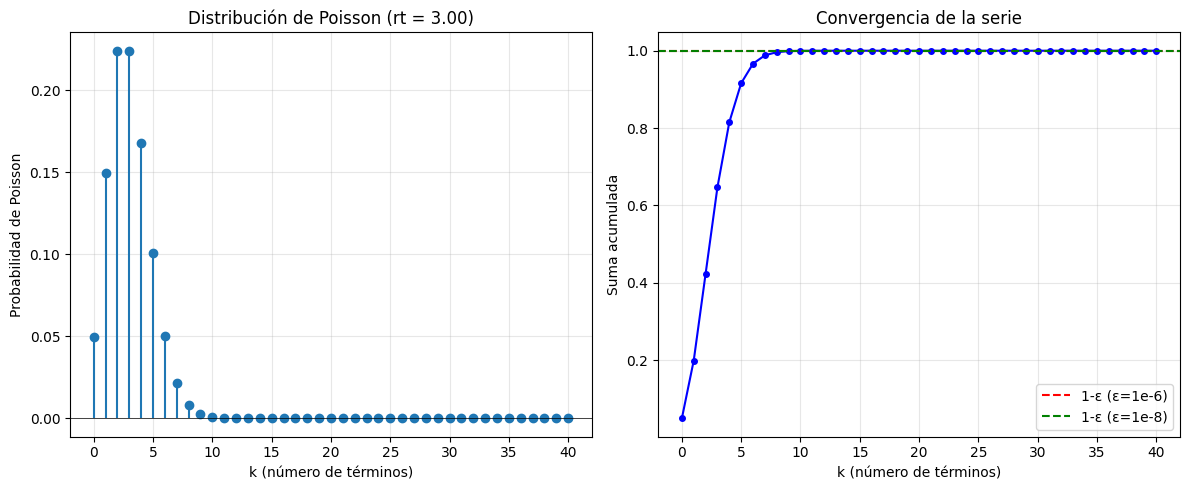


Para t=1.0, rt=6.00:


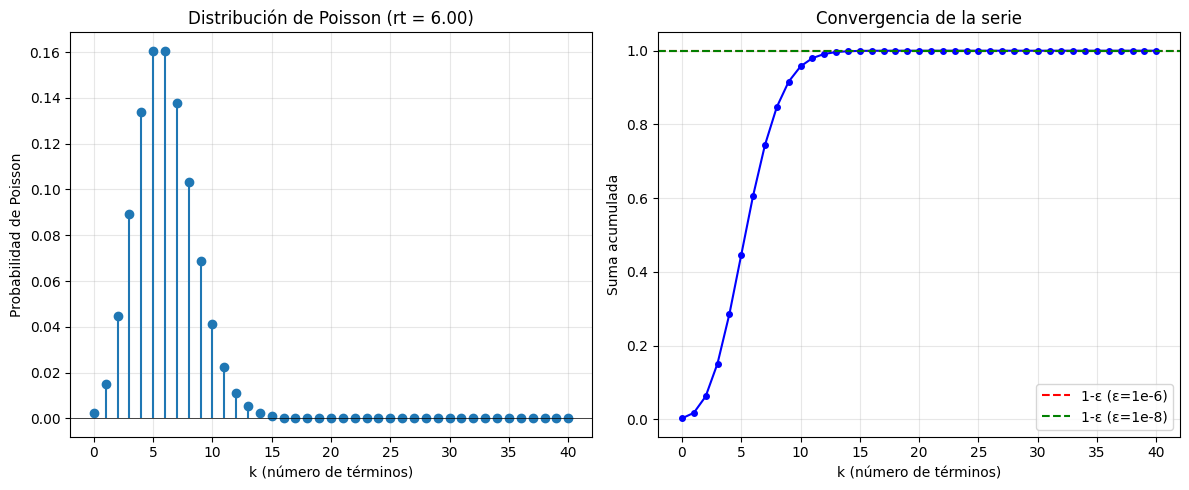


Para t=5.0, rt=30.00:


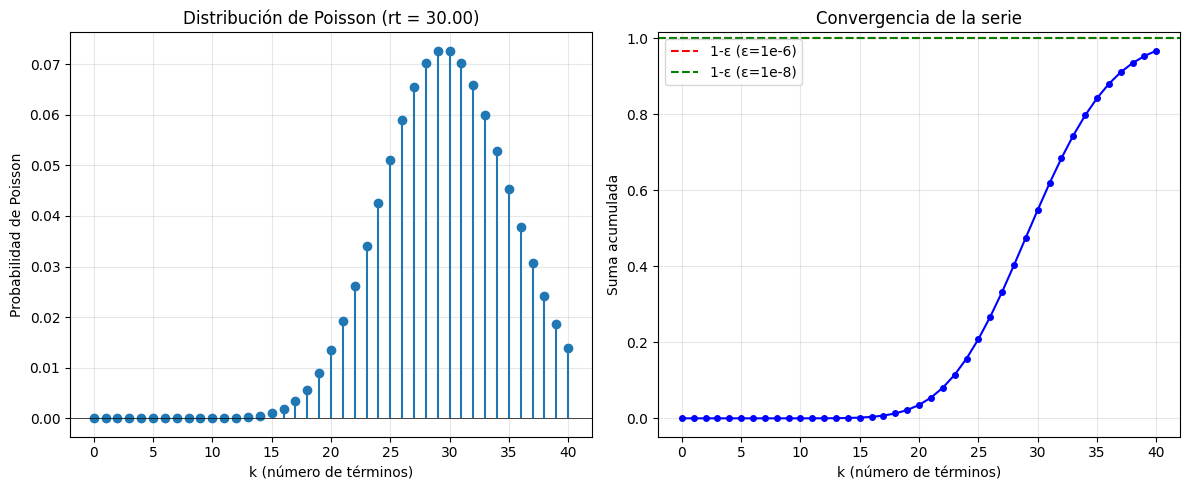

In [ ]:
# Visualizar convergencia para rt = r * 0.5, r * 1, r * 5
R_np_for_r_global = np.array(R.tolist(), dtype=float)
r_global_sympy, _ = calcular_parametros_uniformizacion(R_np_for_r_global)
r_global = float(r_global_sympy) # Especicificamos que los datos si sean flotantentes (float)

print("\nVisualización de convergencia de la serie de Poisson:")
for t in [0.5, 1.0, 5.0]:
    rt = r_global * t
    print(f"\nPara t={t}, rt={rt:.2f}:")
    visualizar_convergencia_poisson(rt, M_max=40)

 ## <span style="color:teal;"> **Conclusiones**</span>

 ### 1. Validación del método de uniformización

Se ha implementado exitosamente el método de uniformización para calcular
la matriz P(t) a partir de la matriz de tasas R. Los resultados obtenidos
cumplen con las propiedades teóricas esperadas:

* **Propiedad estocástica**: Cada fila de $P(t)$ suma 1
*  **Chapman-Kolmogorov**: $P(1) = P(0.5)·P(0.5$) con error < 10⁻⁸
* **No negatividad**: Todas las entradas de $P(t)$ son ≥ 0


### 2. Análisis del comportamiento

- **Para tiempos pequeños $(t ≤ 1)$**:
  - El método del teorema usa el valor mínimo de M
  - El método de tolerancia requiere entre 18-24 términos
  - Ambos producen resultados equivalentes

- **Para tiempos grandes $(t = 5)$**:
  - Ambos métodos requieren M ≈ 57-58 términos
  - La fórmula del teorema es una excelente aproximación
  - La tolerancia ε se alcanza automáticamente

### 3. Interpretación física

La matriz $P(t)$ obtenida muestra cómo evoluciona el sistema:
- En t pequeño $(0.5)$: Mayor probabilidad de permanecer en el mismo estado
- En $t = 1$: El sistema comienza a mezclarse
- En $t = 5$: Se alcanza un comportamiento cercano al estado estacionario
  (las filas de $P(5)$ son muy similares entre sí)

### 4. Limitaciones

**Limitaciones del método:**
- Requiere calcular factoriales
- La convergencia es lenta si rt es muy grande $(t > 100)$
- No es eficiente para matrices de muy grande dimensión $(n > 1000)$


### <span style="color:teal;"> **Conclusión** </teal>

El método de uniformización es una herramienta **robusta y precisa** para
calcular $P(t)$ en cadenas de Markov en tiempo continuo. Ambos enfoques
implementados son válidos, pero el **método con tolerancia ε** es
preferible cuando se requiere garantía de precisión, mientras que la
**fórmula del teorema** es útil para estimaciones rápidas.

La verificación de Chapman-Kolmogorov confirma la consistencia de los
resultados, demostrando la correcta implementación del algoritmo.